In [214]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import json

import warnings
warnings.filterwarnings("ignore")

plt.style.use('fivethirtyeight')
%matplotlib inline

In [215]:
with open("optimal_bins.json", "r") as f:
    optimal_bins = json.load(f)

In [216]:
data = pd.read_csv("tqc_clean.csv")
data = data[['months', 'act0', 'act1', 'CPUE', 'biomass']]
data.head()

,months,act0,act1,CPUE,biomass
0,3,-0.911334,-0.843671,-1.0,-1.0
1,4,-0.964028,-0.703425,-1.0,-1.0
2,5,-0.964028,-0.904936,-1.0,-1.0
3,6,-0.884734,-0.851039,-1.0,-1.0
4,7,-0.839049,-0.761919,-1.0,-1.0


In [229]:
all_vars = ['act0', 'act1', 'CPUE', 'biomass']

def bin_mapper(val, bins):
    
    def one_hot_encode(curr_bin, all_bins):
        return all_bins.index(curr_bin)
        
    for curr_bin in bins:
        left, right = curr_bin
        if left <= val < right:
            return one_hot_encode(curr_bin, bins)
    return len(bins)

def inverse_one_hot_encode(month, val):
    bin_set = optimal_bins[f"('act0', 'act1')_{month}"]
    return bin_set[val]

def find_optimal_bins(row, var):
    month = int(row['months'])
    if 'act' in var:
        bin_key = f"('act0', 'act1')_{month}"
    else:
        bin_key = f"{var}_{month}"
    
    bin_set = optimal_bins[bin_key]
    return bin_mapper(row[var], bin_set)

def preprocess_data(data):    
    for var in all_vars:
        find_optimal_bins_for_var = lambda row: find_optimal_bins(row, var)
        data[f"{var}_bin"] = optimized_data.apply(find_optimal_bins_for_var, axis=1)
    data = data.drop(columns=all_vars)
    return data

preprocessed_data = preprocess_data(data)
preprocessed_data.head()

,months,act0_bin,act1_bin,CPUE_bin,biomass_bin
0,3,1,2,0,0
1,4,3,3,0,0
2,5,3,3,0,0
3,6,3,3,0,0
4,7,3,3,0,0


In [230]:
SEED = 42
X, y0, y1 = preprocessed_data[['months', 'CPUE_bin', 'biomass_bin']], preprocessed_data['act0_bin'], preprocessed_data['act1_bin']
X0_train, X0_test, y0_train, y0_test = train_test_split(X, y0, test_size=0.2, random_state=SEED, stratify=y0)
X1_train, X1_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, random_state=SEED, stratify=y1)

In [231]:
!pip install lightgbm xgboost
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [232]:
lgb_model_minnow = LGBMClassifier(
    objective="multiclass",
    num_class=y0_train.nunique(),
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED
)

lgb_model_minnow.fit(
    X0_train,
    y0_train,
    categorical_feature=["months", "CPUE_bin", "biomass_bin"]
)

lgb_model_fukui = LGBMClassifier(
    objective="multiclass",
    num_class=y1_train.nunique(),
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED
)

lgb_model_fukui.fit(
    X1_train,
    y1_train,
    categorical_feature=["months", "CPUE_bin", "biomass_bin"]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000255 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20
[LightGBM] [Info] Number of data points in the train set: 39600, number of used features: 3
[LightGBM] [Info] Start training from score -2.203609
[LightGBM] [Info] Start training from score -2.342776
[LightGBM] [Info] Start training from score -2.810889
[LightGBM] [Info] Start training from score -0.365407
[LightGBM] [Info] Start training from score -3.232222
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [233]:
lgb_y0_pred = lgb_model_minnow.predict(X0_test)
lgb_y0_prob = lgb_model_minnow.predict_proba(X0_test)

lgb_y1_pred = lgb_model_fukui.predict(X1_test)
lgb_y1_prob = lgb_model_fukui.predict_proba(X1_test)

In [234]:
from sklearn.metrics import accuracy_score, f1_score

lgb_y0_acc = accuracy_score(y0_test, lgb_y0_pred)
lgb_y0_f1 = f1_score(y0_test, lgb_y0_pred, average='weighted')
lgb_y0_mae_bins = np.mean(np.abs(y0_test.to_numpy() - lgb_y0_pred))

lgb_y1_acc = accuracy_score(y1_test, lgb_y1_pred)
lgb_y1_f1 = f1_score(y1_test, lgb_y1_pred, average='weighted')
lgb_y1_mae_bins = np.mean(np.abs(y1_test.to_numpy() - lgb_y1_pred))

print("Minnow Accuracy:", lgb_y0_acc)
print("Minnow Weighted F1 Score:", lgb_y0_f1)
print("Minnow MAE:", lgb_y0_mae_bins)
print("\n")
print("Fukui Accuracy:", lgb_y1_acc)
print("Fukui Weighted F1 Score:", lgb_y0_f1)
print("Fukui MAE:", lgb_y1_mae_bins)

Minnow Accuracy: 0.972929292929293
Minnow Weighted F1 Score: 0.9746941188590774
Minnow MAE: 0.02707070707070707


Fukui Accuracy: 0.944040404040404
Fukui Weighted F1 Score: 0.9746941188590774
Fukui MAE: 0.056262626262626264


In [223]:
xgboost_model_minnow = XGBClassifier(
    objective="multi:softprob",
    num_class=y0.nunique(),
    tree_method="hist",
    enable_categorical=True,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED
)

xgboost_model_minnow.fit(X0_train, y0_train)

xgboost_model_fukui = XGBClassifier(
    objective="multi:softprob",
    num_class=y1.nunique(),
    tree_method="hist",
    enable_categorical=True,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED
)

xgboost_model_fukui.fit(X1_train, y1_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [224]:
xgboost_y0_pred = xgboost_model_minnow.predict(X0_test)
xgboost_y0_prob = xgboost_model_minnow.predict_proba(X0_test)

xgboost_y1_pred = xgboost_model_fukui.predict(X1_test)
xgboost_y1_prob = xgboost_model_fukui.predict_proba(X1_test)

In [225]:
xgboost_y0_acc = accuracy_score(y0_test, xgboost_y0_pred)
xgboost_y0_f1 = f1_score(y0_test, xgboost_y0_pred, average='weighted')
xgboost_y0_mae_bins = np.mean(np.abs(y0_test.to_numpy() - xgboost_y0_pred))

xgboost_y1_acc = accuracy_score(y1_test, xgboost_y1_pred)
xgboost_y1_f1 = f1_score(y1_test, xgboost_y1_pred, average='weighted')
xgboost_y1_mae_bins = np.mean(np.abs(y1_test.to_numpy() - xgboost_y1_pred))

print("Minnow Accuracy:", xgboost_y0_acc)
print("Minnow Weighted F1 Score:", xgboost_y0_f1)
print("Minnow MAE:", xgboost_y0_mae_bins)
print("\n")
print("Fukui Accuracy:", xgboost_y1_acc)
print("Fukui Weighted F1 Score:", xgboost_y0_f1)
print("Fukui MAE:", xgboost_y1_mae_bins)

Minnow Accuracy: 0.9725252525252526
Minnow Weighted F1 Score: 0.9742298862379475
Minnow MAE: 0.027474747474747475


Fukui Accuracy: 0.9402020202020202
Fukui Weighted F1 Score: 0.9742298862379475
Fukui MAE: 0.0601010101010101


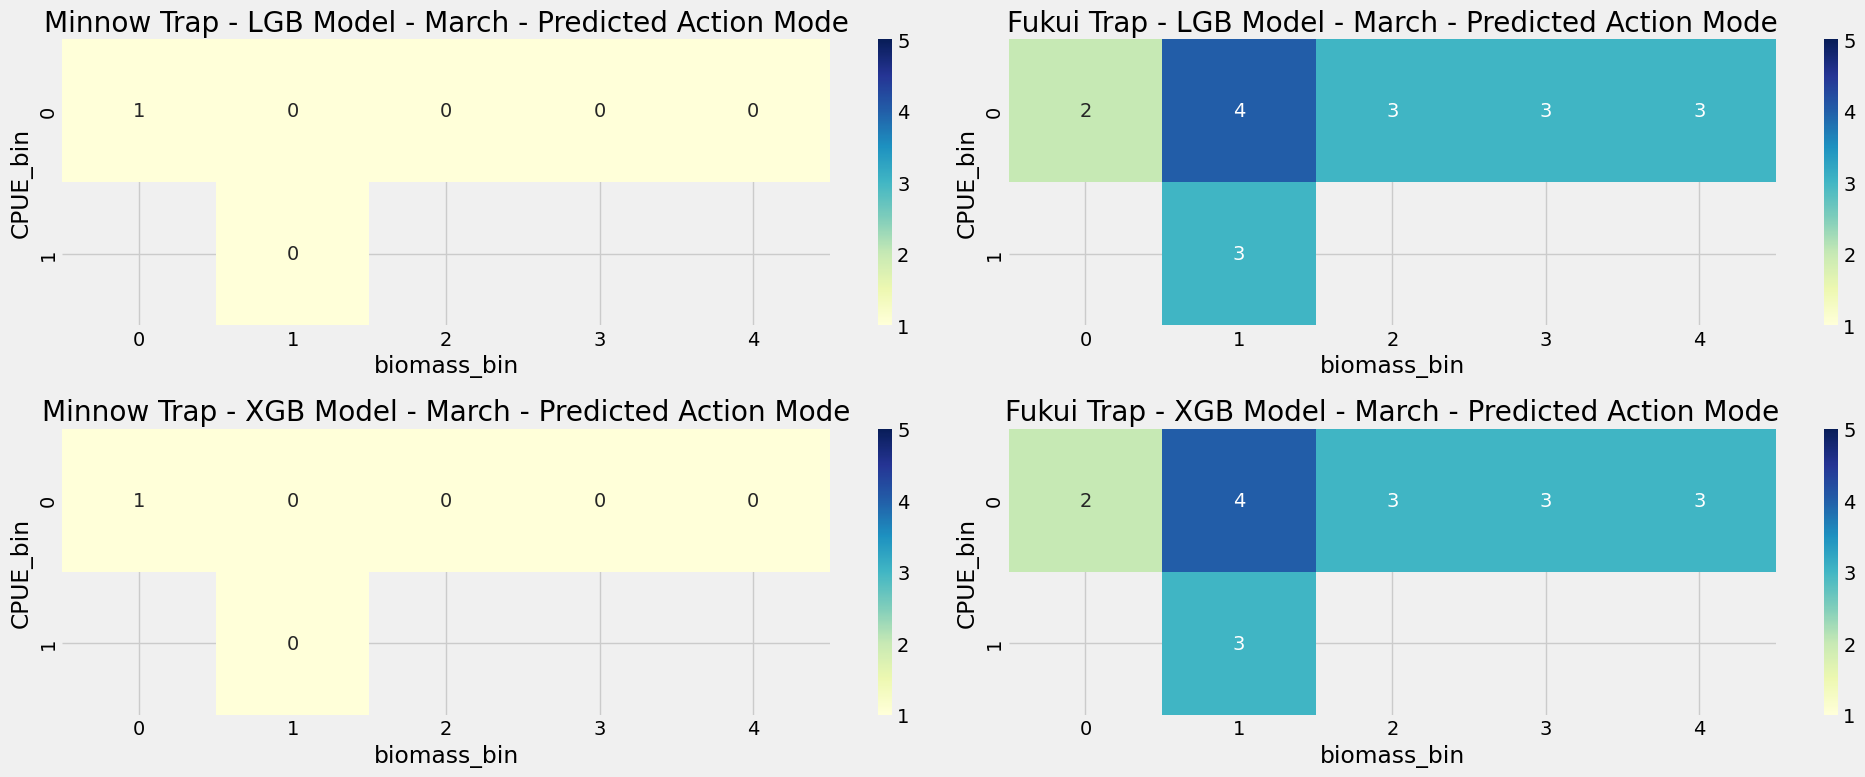

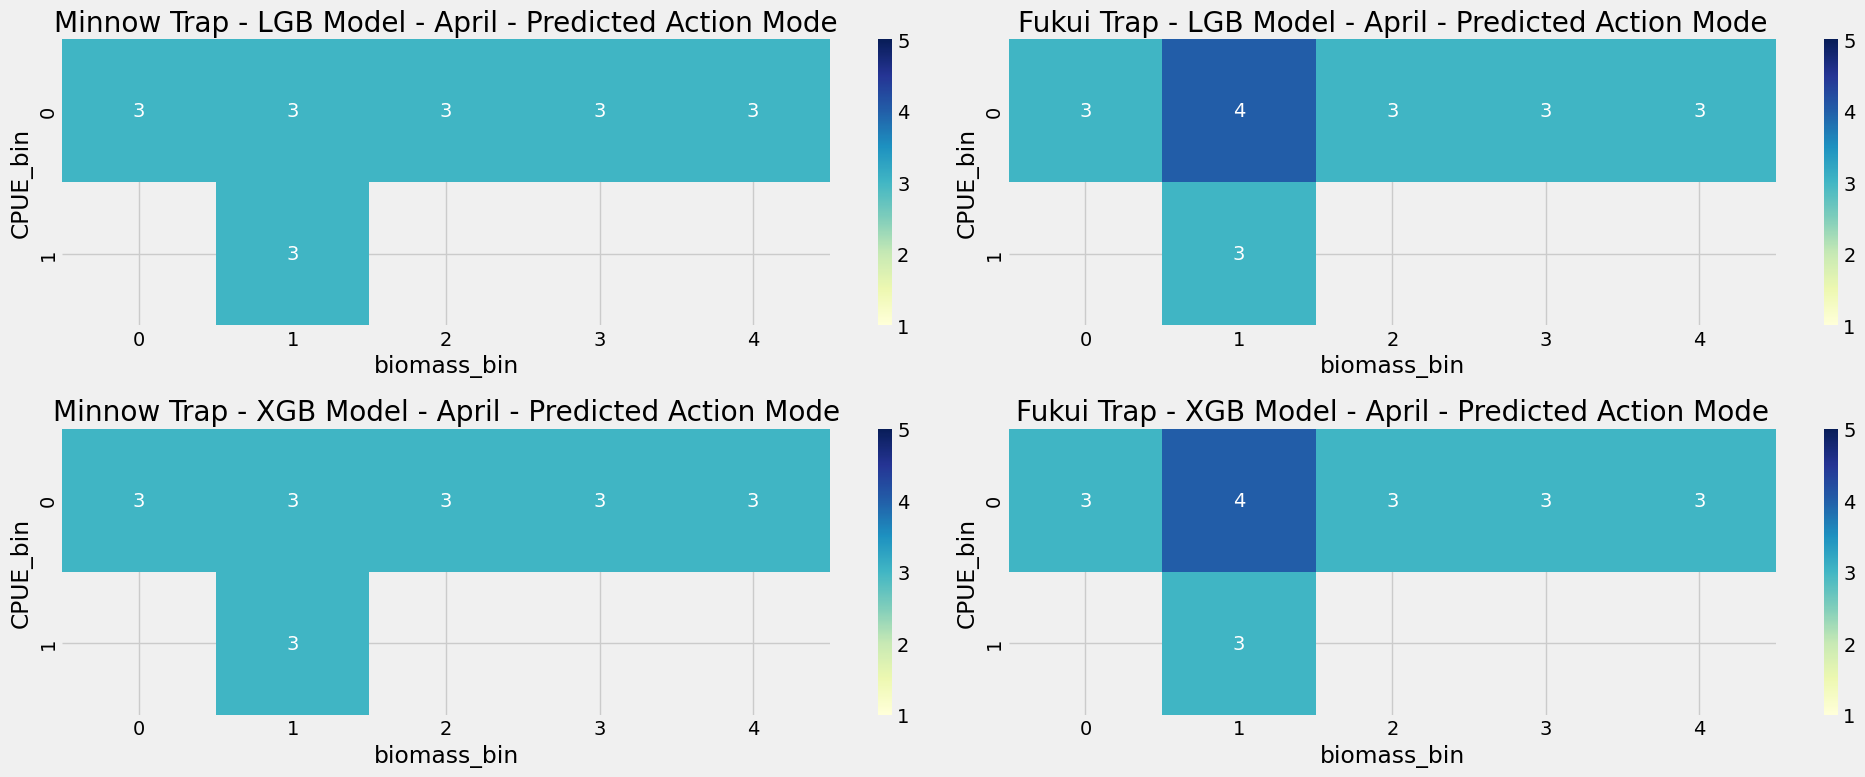

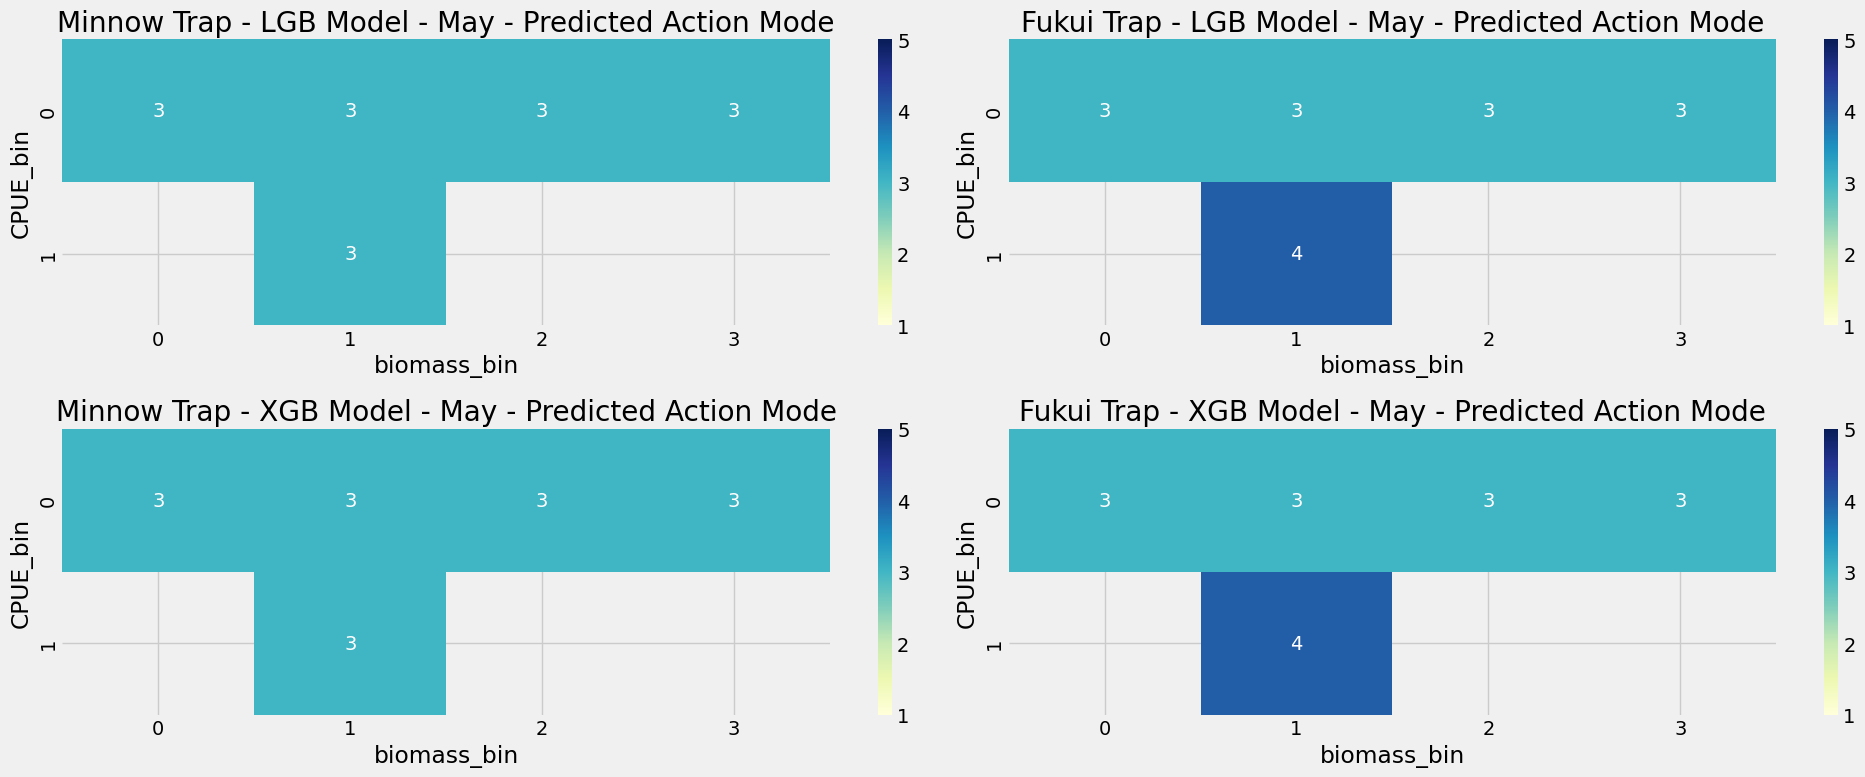

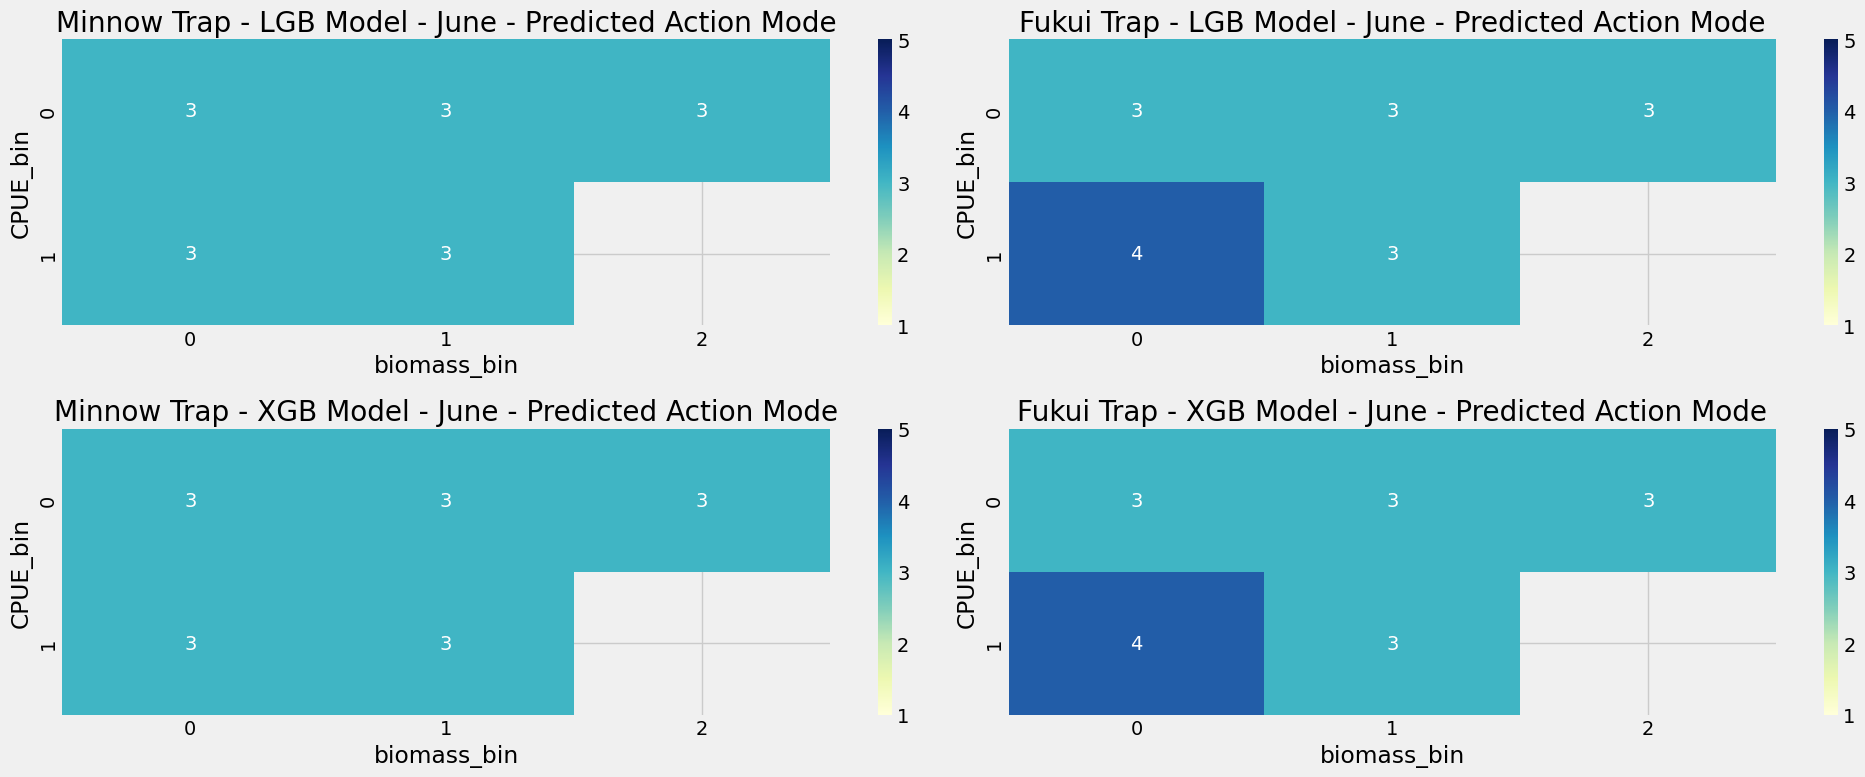

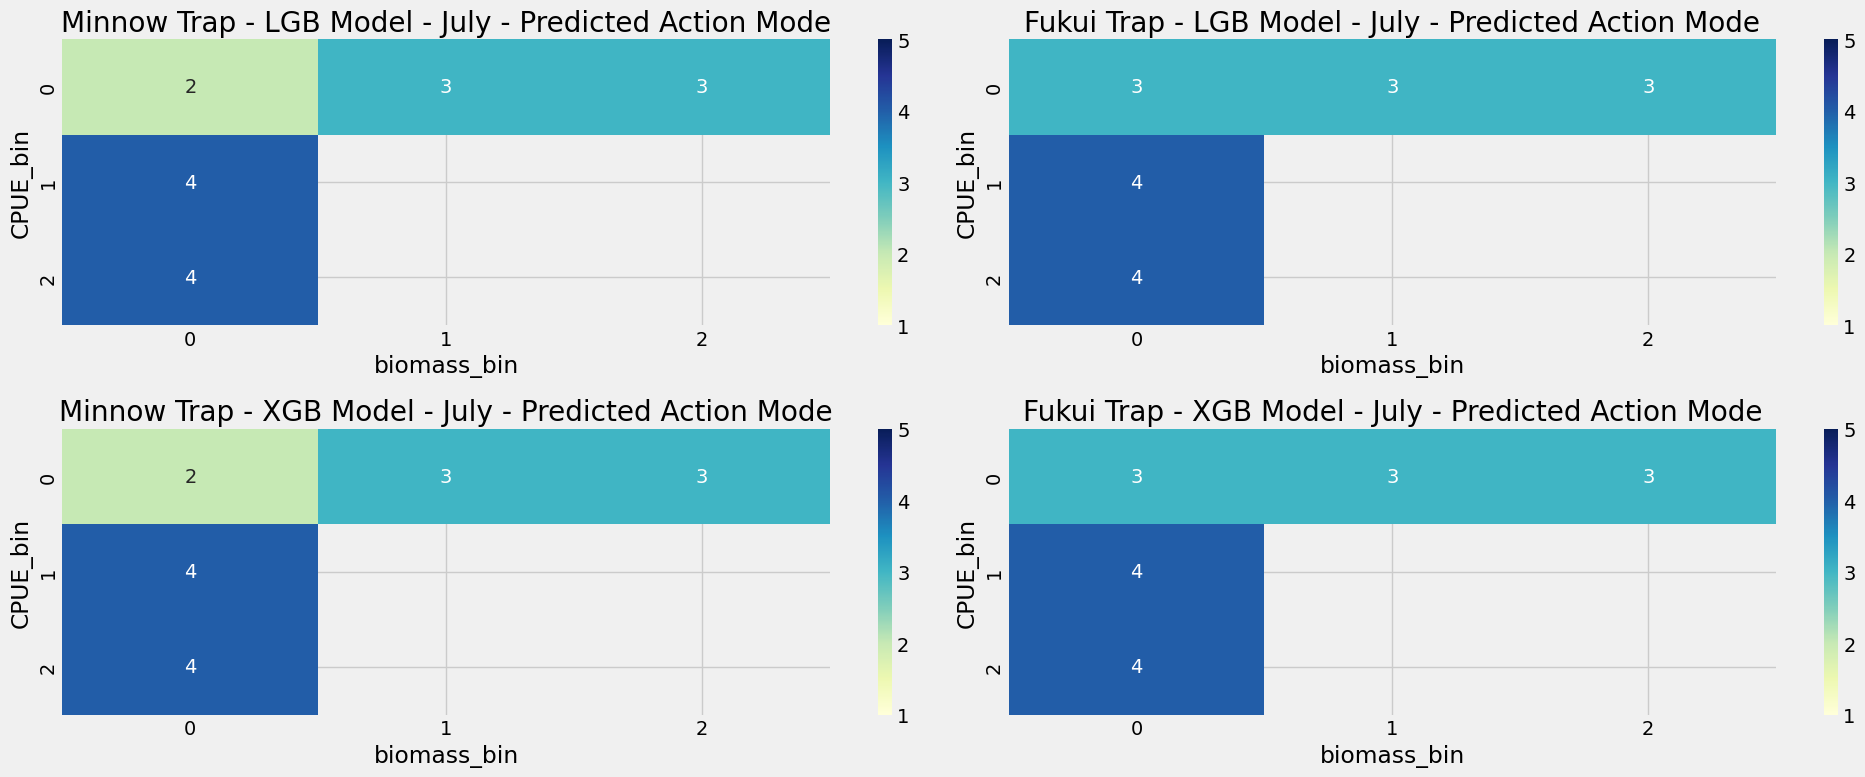

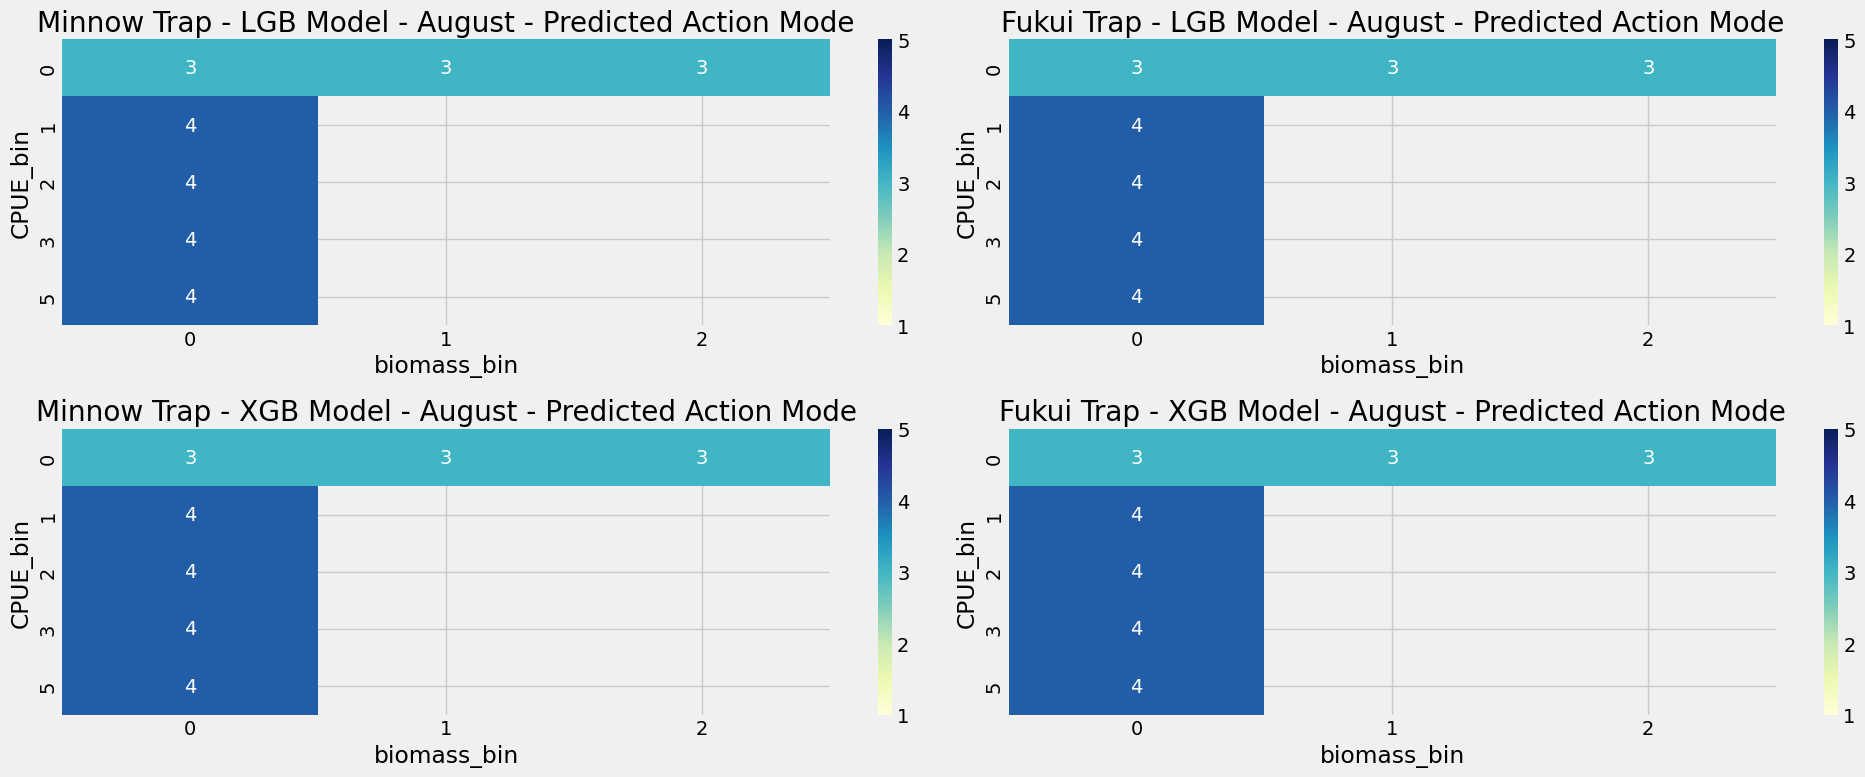

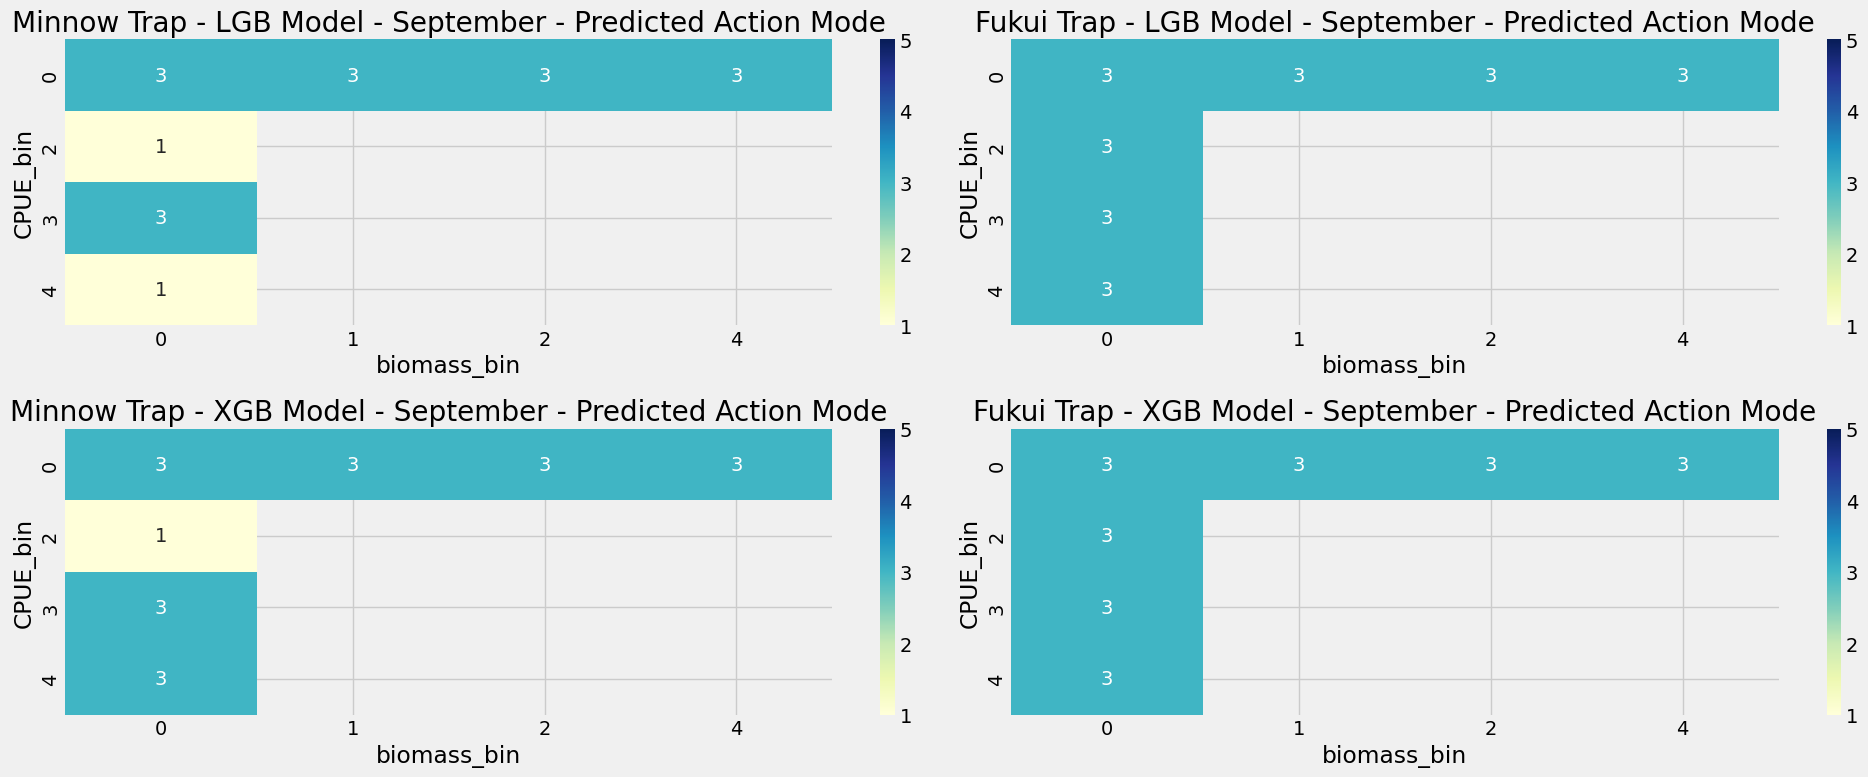

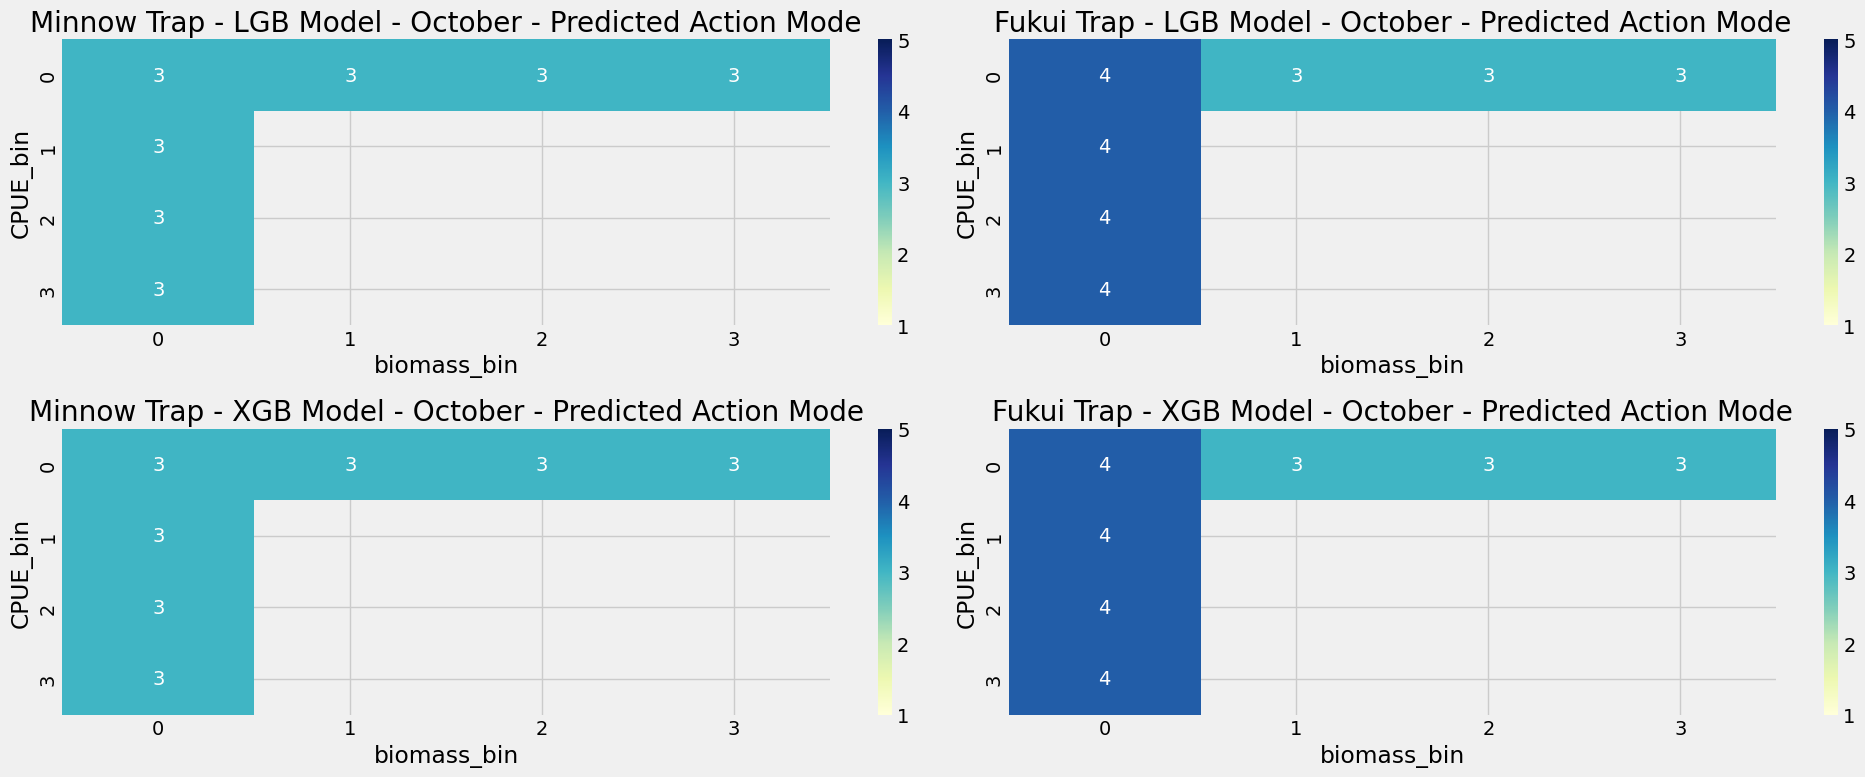

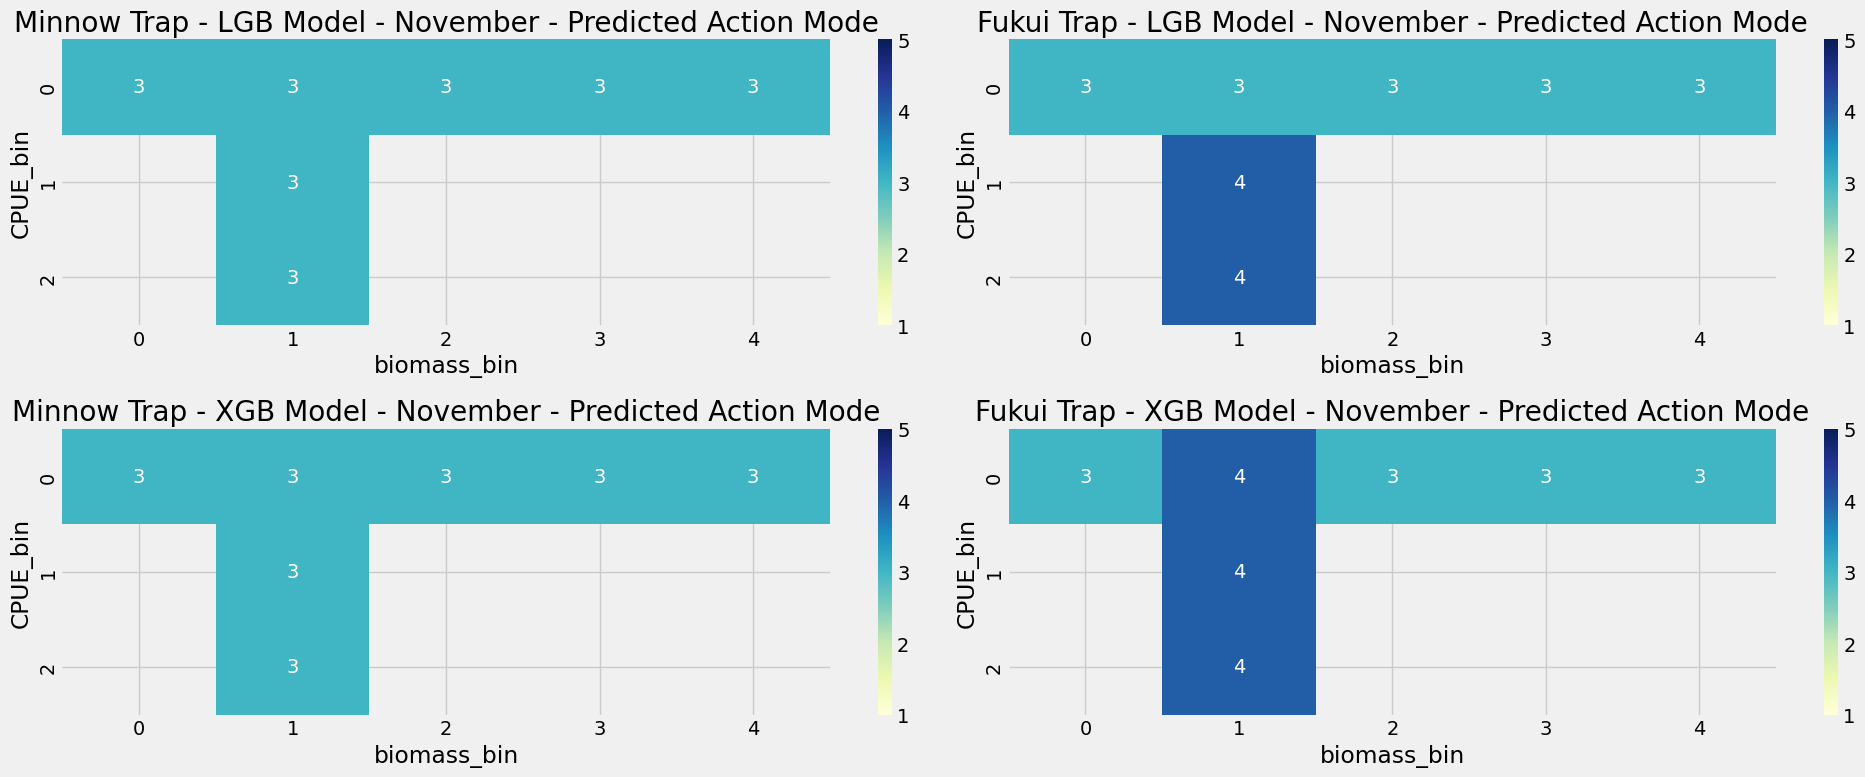

In [226]:
import seaborn as sns

minnow_df = X0_test.copy()
minnow_df['actual'] = y0_test
minnow_df['lgb_pred'] = lgb_y0_pred
minnow_df['xgb_pred'] = xgboost_y0_pred

fukui_df = X1_test.copy()
fukui_df['actual'] = y1_test
fukui_df['lgb_pred'] = lgb_y1_pred
fukui_df['xgb_pred'] = xgboost_y1_pred

month_dict = {3: "March", 4: "April", 5: "May", 6: "June", 7: "July", 8:"August", 9: "September", 10: "October", 11: "November"}
trap_dfs = [minnow_df, fukui_df]
trap_dict = {0: "Minnow", 1: "Fukui"}

for month in month_dict.keys():
    fig, axes = plt.subplots(2, 2, figsize=(20,8))
    for i in range(2):
        df = trap_dfs[i]
        curr_month = df[df["months"] == month]
    
        lgb_preds = pd.pivot_table(data = curr_month, index="CPUE_bin", columns="biomass_bin", values="lgb_pred", aggfunc=lambda x: x.mode().iloc[0])
        xgb_preds = pd.pivot_table(data = curr_month, index="CPUE_bin", columns="biomass_bin", values="xgb_pred", aggfunc=lambda x: x.mode().iloc[0])
    
    
        sns.heatmap(lgb_preds, annot=True, cmap="YlGnBu", vmin=1, vmax=5, ax=axes[0, i])
        axes[0, i].set_title(f"{trap_dict[i]} Trap - LGB Model - {month_dict[month]} - Predicted Action Mode")

        sns.heatmap(xgb_preds, annot=True, cmap="YlGnBu", vmin=1, vmax=5, ax=axes[1, i])
        axes[1, i].set_title(f"{trap_dict[i]} Trap - XGB Model - {month_dict[month]} - Predicted Action Mode")
    
    plt.tight_layout()
    plt.show()